# 모델배포개론 Day8 - Quest (HuggingFace Model)    by 김민수

< Overview >
- HuggingFace 모델은 Helsinki-NLP ko-en 한-영 번역기 모델을 선택. 
- 비교적 단순하고 평이한 모델이었기에 코드 작성 및 디버깅에 큰 어려움은 없었음.
- 백엔드: FastAPI 적용. 추론 엔드포인트(POST /predict) 구현 및 Pydantic 입력 검증 구현. 비동기 추론 (run_in_executor) 구현.
- 프론트: Streamlit 적용. 사용자 입력란 및 번역 결과 출력란 출력. 
- API Key 인증 모듈 적용. 
- 에러 처리 코드 구현. 

< 작업 결과 >
- 과제 요구사항 모두 포함하여 Front/Back-end 구현 완료!
- 한글 문장 입력 시 적절한 영문 번역문이 출력되는 것도 확인되었으나, 문장이 길어지거나 의역이 필요한 문장 같은 경우에는 번역 품질이 만족스럽지 못하였음.
- 추후 번역 모델을 재작업할 기회가 생긴다면 Helsinki 모델 외 다른 NLP 모델을 사용하여 번역 품질을 비교해 보고자 함. 

### #1. 작업 환경 세팅 및 모델 테스트 

In [4]:
import sys
print(f"Python 경로: {sys.executable}")

Python 경로: /home/harry/model-serving-course/.venv_harry/bin/python


In [6]:
import torch
import fastapi
import streamlit

print(f"PyTorch:   {torch.__version__}")
print(f"FastAPI:   {fastapi.__version__}")
print(f"Streamlit: {streamlit.__version__}")

PyTorch:   2.4.1+cu121
FastAPI:   0.115.0
Streamlit: 1.38.0


In [18]:
# 실습용 노트북 파일에 제시된 모델 테스트 실습

from transformers import pipeline

classifier = pipeline("text-classification", model="snunlp/KR-FinBert-SC")

result = classifier("오늘 주가가 크게 올랐습니다")
print(result)
# [{'label': 'positive', 'score': 0.95}]


/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[{'label': 'positive', 'score': 0.9987346529960632}]


In [26]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.7 MB/s  0:00:00 eta 0:00:01


#### 실습용 모델 선택 및 사전 테스트 (Helsinki-NLP/ko-en 번역기)

In [1]:
from transformers import pipeline
from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-ko-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

text = "안녕하세요. 오늘 날씨가 정말 좋네요."
inputs = tokenizer(text, return_tensors="pt", padding=True)
translated = model.generate(**inputs)
result = tokenizer.decode(translated[0], skip_special_tokens=True)


# 번역 파이프라인 생성
# translator = pipeline(task="translation", model="Helsinki-NLP/opus-mt-ko-en")

# # 테스트 문장
# text = "안녕하세요. 오늘 날씨가 정말 좋네요."

# # 번역
# result = translator(text)

print(result)

/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended

Hi, it's a great day.


In [3]:
import os 
print(os.getcwd())

/home/harry/model-serving-course


In [4]:
import os

dirs = ["app", "models", "frontend"]
for d in dirs:
    os.makedirs(f"my-project/{d}", exist_ok=True)

print(os.listdir("my-project"))

['app', 'frontend', 'models']


### #2. API-KEY 인증 및 입/출력 스키마 모듈

In [10]:
%%writefile my-project/app/auth.py
"""
API Key 인증 모듈
"""
from fastapi import Security, HTTPException, status
from fastapi.security import APIKeyHeader

# ── API Key 설정 ──────────────────────────
API_KEY = "my-key-12345"        
API_KEY_NAME = "X-API-Key"

api_key_header = APIKeyHeader(name=API_KEY_NAME, auto_error=False)


def verify_api_key(api_key: str = Security(api_key_header)):
    """API Key 검증"""
    if api_key is None:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail="API Key가 없습니다. 헤더에 X-API-Key를 포함하세요."
        )
    if api_key != API_KEY:
        raise HTTPException(
            status_code=status.HTTP_403_FORBIDDEN,
            detail="유효하지 않은 API Key입니다."
        )
    return api_key


Overwriting my-project/app/auth.py


In [6]:
%%writefile my-project/app/schemas.py

from pydantic import BaseModel, Field

# ── Request 스키마 ──────────────────────────
class PredictRequest(BaseModel):
    text: str = Field(
        ...,
        min_length=1,
        max_length=5000,
        description="한국어 번역 입력 텍스트"
    )


# ── Response 스키마 ──────────────────────────
class PredictResponse(BaseModel):
    success: bool = Field(
        ...,
        description="요청 성공 여부"
    )
    translated_text: str = Field(
        ...,
        description="영어 번역 결과"
    )
    source_text: str = Field(
        ...,
        description="원본 한국어 텍스트"
    )
    model_name: str = Field(
        default="Helsinki-NLP/opus-mt-ko-en",
        description="사용된 번역 모델"
    )


# ── 에러 응답 스키마 ──────────────────────────
class ErrorResponse(BaseModel):
    success: bool = False
    error: str = Field(
        ...,
        description="에러 메시지"
    )




Writing my-project/app/schemas.py


### #3. 추론 모델 구현 및 테스트

In [8]:
%%writefile my-project/app/model.py
"""
모델 로드 및 추론 로직 - Helsinki ko-en 번역 모델
"""
from transformers import MarianMTModel, MarianTokenizer
import torch
import time


# ── 모델 클래스 ──────────────────────────
class TranslationModel:
    """Helsinki-NLP/opus-mt-ko-en 번역 모델 래퍼"""

    def __init__(self, model_name: str = "Helsinki-NLP/opus-mt-ko-en"):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.is_loaded = False

    def load(self):
        """모델 및 토크나이저 로드"""
        print(f"🔄 모델 로딩 중: {self.model_name}")
        start = time.time()

        self.tokenizer = MarianTokenizer.from_pretrained(self.model_name)
        self.model = MarianMTModel.from_pretrained(self.model_name)
        self.model.eval()

        elapsed = time.time() - start
        self.is_loaded = True
        print(f"✅ 모델 로딩 완료 ({elapsed:.2f}초)")

    def predict(self, text: str) -> dict:
        """
        한국어 → 영어 번역 추론

        Args:
            text: 한국어 입력 텍스트

        Returns:
            dict: 번역 결과 및 메타데이터
        """
        if not self.is_loaded:
            raise RuntimeError("모델이 로드되지 않았습니다. load()를 먼저 호출하세요.")

        start = time.time()

        # 토크나이징
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        )

        # 추론
        with torch.no_grad():
            translated = self.model.generate(**inputs)

        # 디코딩
        result = self.tokenizer.decode(translated[0], skip_special_tokens=True)

        elapsed = time.time() - start

        return {
            "translated_text": result,
            "source_text": text,
            "inference_time": round(elapsed, 4),
            "model_name": self.model_name
        }

    def unload(self):
        """메모리 해제"""
        del self.tokenizer, self.model
        self.tokenizer = None
        self.model = None
        self.is_loaded = False
        print("✅ 모델 메모리 해제 완료")


# ── 싱글톤 인스턴스 ──────────────────────────
translation_model = TranslationModel()



Writing my-project/app/model.py


In [9]:
import sys
sys.path.append("my-project/app")

from model import translation_model

# 모델 로드
translation_model.load()

# 단일 문장 테스트
result = translation_model.predict("안녕하세요. 오늘 날씨가 정말 좋네요.")
print(f"원문: {result['source_text']}")
print(f"번역: {result['translated_text']}")
print(f"추론 시간: {result['inference_time']}초")


🔄 모델 로딩 중: Helsinki-NLP/opus-mt-ko-en


/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


✅ 모델 로딩 완료 (4.23초)
원문: 안녕하세요. 오늘 날씨가 정말 좋네요.
번역: Hi, it's a great day.
추론 시간: 0.4531초


### #4. Back-end 모듈 (FastAPI)

In [22]:
%%writefile my-project/app/main.py
"""
FastAPI 메인 애플리케이션 - Helsinki ko-en 번역 모델 서빙
"""
from fastapi import FastAPI, HTTPException, Depends
from contextlib import asynccontextmanager
from transformers import MarianMTModel, MarianTokenizer
import torch
import asyncio

from functools import partial
from schemas import PredictRequest, PredictResponse, ErrorResponse
from model import translation_model
from auth import verify_api_key


# ── 전역 변수 ──────────────────────────
MODEL_NAME = "Helsinki-NLP/opus-mt-ko-en"
tokenizer = None
model = None



# ── 앱 시작/종료 ──────────────────────────
@asynccontextmanager
async def lifespan(app: FastAPI):
    """서버 시작 시 모델 로드, 종료 시 메모리 해제"""
    loop = asyncio.get_event_loop()
    await loop.run_in_executor(None, translation_model.load)   
    yield
    translation_model.unload()


# ── FastAPI 앱 생성 ──────────────────────────
app = FastAPI(
    title="Ko-En 번역 API",
    description="Helsinki-NLP/opus-mt-ko-en 모델 한영 번역 API",
    version="1.0.0",
    lifespan=lifespan
)


# ── 엔드포인트 ──────────────────────────
@app.get("/")
def root():
    """헬스 체크 (인증 불필요)"""
    return {"status": "ok", "model": translation_model.model_name}


@app.get("/health")
def health():
    """모델 로딩 상태 확인 (인증 불필요)"""
    return {
        "status": "ready" if translation_model.is_loaded else "loading",
        "model": translation_model.model_name
    }


@app.post(
    "/predict",
    response_model=PredictResponse,
    responses={
        401: {"model": ErrorResponse, "description": "API Key 없음"},
        403: {"model": ErrorResponse, "description": "API Key 불일치"},
        422: {"model": ErrorResponse, "description": "입력값 오류"},
        500: {"model": ErrorResponse, "description": "모델 추론 오류"},
        503: {"model": ErrorResponse, "description": "모델 로딩 중"},
    }
)
async def predict(
    request: PredictRequest,
    api_key: str = Depends(verify_api_key)   # API Key 인증
):
    """한국어 → 영어 번역 (비동기 추론)"""

    # 모델 준비 확인
    if not translation_model.is_loaded:
        raise HTTPException(
            status_code=503,
            detail="모델이 아직 로딩 중입니다. 잠시 후 다시 시도하세요."
        )

    # 입력값 검증
    if not request.text.strip():
        raise HTTPException(
            status_code=422,
            detail="빈 텍스트는 번역할 수 없습니다."
        )

    try:
        ### 비동기 추론 (run_in_executor로 블로킹 방지)
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(
            None,
            partial(translation_model.predict, request.text)
        )

        return PredictResponse(
            success=True,
            translated_text=result["translated_text"],
            source_text=result["source_text"],
            model_name=result["model_name"]
        )

    except Exception as e:
        raise HTTPException(
            status_code=500,
            detail=f"모델 추론 오류: {str(e)}"
        )


Overwriting my-project/app/main.py


In [ ]:
import subprocess
import time

# 서버 백그라운드 실행
server = subprocess.Popen(
    ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"],
    cwd="my-project/app"
)

time.sleep(3)  # 서버 시작 대기
print("✅ 서버 실행 중: http://localhost:8000")

✅ 서버 실행 중: http://localhost:8000


INFO:     Started server process [70683]
INFO:     Waiting for application startup.
/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


🔄 모델 로딩 중: Helsinki-NLP/opus-mt-ko-en


/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


✅ 모델 로딩 완료 (5.08초)


INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


### 백엔드 FastAPI 출력 화면 ###

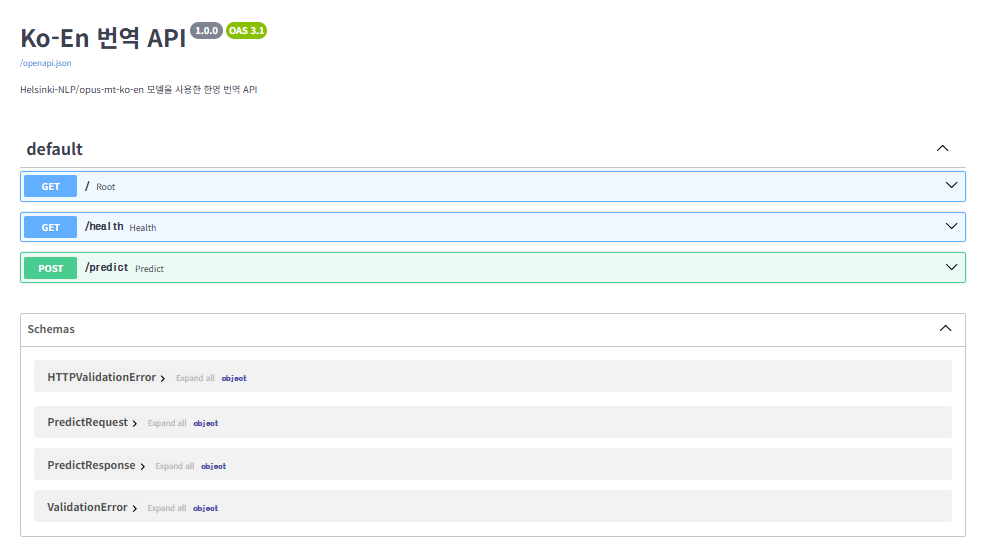

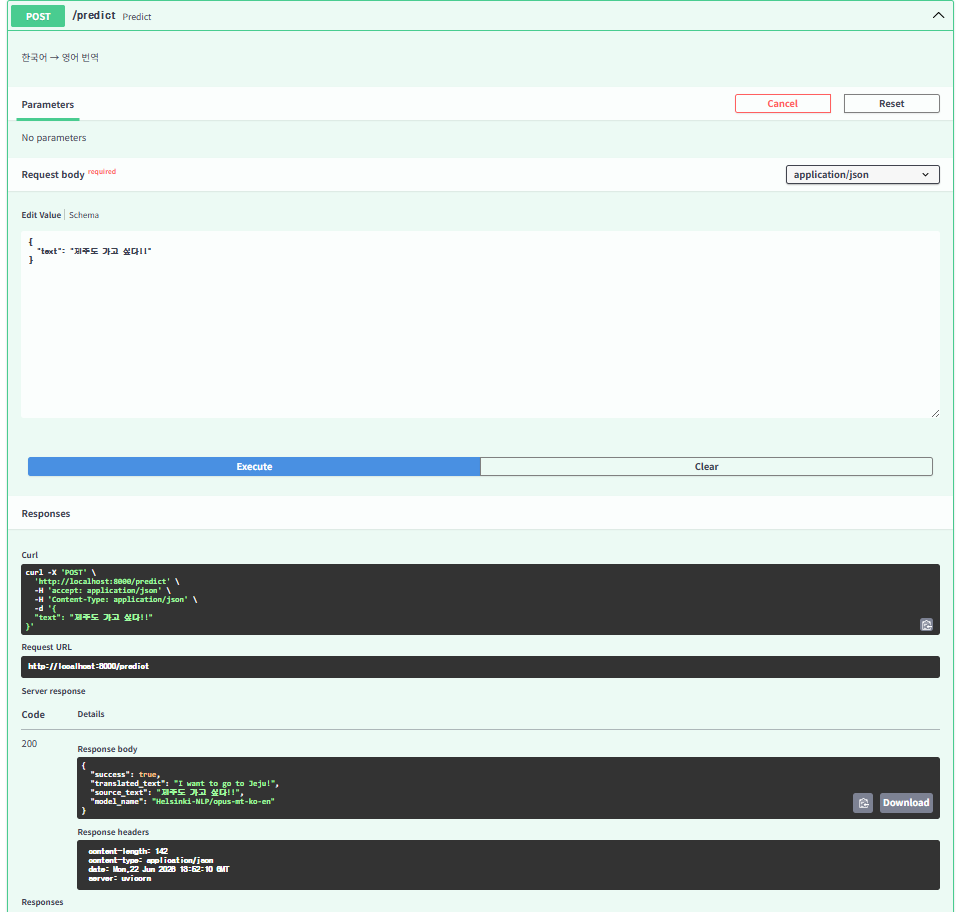

### #5. Front-end 모듈 (Streamlit)

In [6]:
%%writefile my-project/frontend/app.py
"""
Streamlit 프론트엔드 - Helsinki ko-en 번역 서비스
"""
import streamlit as st
import requests
import time

# ── 설정 ──────────────────────────
API_URL = "http://localhost:8000"
API_KEY = "my-key-12345"
HEADERS = {"X-API-Key": API_KEY}

# ── 페이지 설정 ──────────────────────────
st.set_page_config(
    page_title="한영 번역기",
    page_icon="🌐",
    layout="centered"
)

st.title("🌐 한국어 → 영어 번역기")
st.caption("Helsinki-NLP/opus-mt-ko-en 모델 사용")

# ── 서버 상태 확인 ──────────────────────────
def check_server():
    try:
        res = requests.get(f"{API_URL}/health", timeout=3)
        return res.json()
    except Exception:
        return None

status = check_server()

if status is None:
    st.error("❌ 서버에 연결할 수 없습니다.")
    st.code("uvicorn main:app --host 0.0.0.0 --port 8000", language="bash")
    st.stop()
elif status.get("status") == "loading":
    st.warning("⏳ 모델 로딩 중입니다. 잠시 후 다시 시도하세요.")
    st.stop()
else:
    st.success(f"✅ 서버 연결됨 | 모델: {status.get('model')}")

st.divider()

# ── 번역 입력 ──────────────────────────
st.subheader("📝 번역할 텍스트 입력")

input_text = st.text_area(
    label="한국어 텍스트",
    placeholder="번역할 한국어 문장을 입력하세요...",
    height=150,
    max_chars=5000
)

col1, col2 = st.columns([1, 4])
with col1:
    translate_btn = st.button("번역하기 🚀", use_container_width=True)
with col2:
    st.caption(f"입력 글자 수: {len(input_text)} / 5000")

# ── 번역 실행 ──────────────────────────
if translate_btn:
    if not input_text.strip():
        st.warning("⚠️ 텍스트를 입력해주세요.")
    else:
        with st.spinner("번역 중..."):
            try:
                start = time.time()
                res = requests.post(
                    f"{API_URL}/predict",
                    json={"text": input_text},
                    headers=HEADERS,   # API Key 포함
                    timeout=30
                )
                elapsed = time.time() - start

                # 에러 처리
                if res.status_code == 401:
                    st.error("❌ API Key가 없습니다.")
                elif res.status_code == 403:
                    st.error("❌ 유효하지 않은 API Key입니다.")
                elif res.status_code == 422:
                    st.error(f"❌ 입력값 오류: {res.json().get('detail')}")
                elif res.status_code == 503:
                    st.warning("⏳ 모델 로딩 중입니다. 잠시 후 다시 시도하세요.")
                elif res.status_code == 500:
                    st.error(f"❌ 서버 오류: {res.json().get('detail')}")
                elif res.status_code == 200:
                    data = res.json()
                    st.divider()
                    st.subheader("🇺🇸 번역 결과")
                    st.success(data["translated_text"])

                    col1, col2 = st.columns(2)
                    with col1:
                        st.metric("⏱️ 응답 시간", f"{elapsed:.2f}초")
                    with col2:
                        st.metric("📊 입력 글자 수", len(input_text))

            except requests.exceptions.Timeout:
                st.error("❌ 요청 시간 초과.")
            except Exception as e:
                st.error(f"❌ 오류: {str(e)}")

# ── 예시 문장 ──────────────────────────
st.divider()
st.subheader("💡 예시 문장")

examples = [
    "안녕하세요. 오늘 날씨가 정말 좋네요.",
    "인공지능 기술이 빠르게 발전하고 있습니다.",
    "한국 음식은 정말 맛있습니다.",
    "서울은 대한민국의 수도입니다.",
]

for example in examples:
    if st.button(example, use_container_width=True):
        st.session_state["example"] = example
        st.rerun()

if "example" in st.session_state:
    st.info(f"선택된 예시: {st.session_state['example']}")
    del st.session_state["example"]



Overwriting my-project/frontend/app.py


In [26]:
import subprocess
import time

# 1. FastAPI 서버 실행
api = subprocess.Popen(
    ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"],
    cwd="my-project/app"
)

time.sleep(3)
print("✅ API 서버 실행 중: http://localhost:8000")

# 2. Streamlit 실행
frontend = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"],
    cwd="my-project/frontend"
)

time.sleep(3)
print("✅ 프론트엔드 실행 중: http://localhost:8501")


INFO:     Started server process [70759]
INFO:     Waiting for application startup.
/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


🔄 모델 로딩 중: Helsinki-NLP/opus-mt-ko-en
✅ API 서버 실행 중: http://localhost:8000


/home/harry/model-serving-course/.venv_harry/lib/python3.10/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.20.226.61:8501

✅ 모델 로딩 완료 (2.89초)
✅ 모델 메모리 해제 완료


INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


✅ 프론트엔드 실행 중: http://localhost:8501


### 프론트엔드 Streamlit 화면 출력 ###

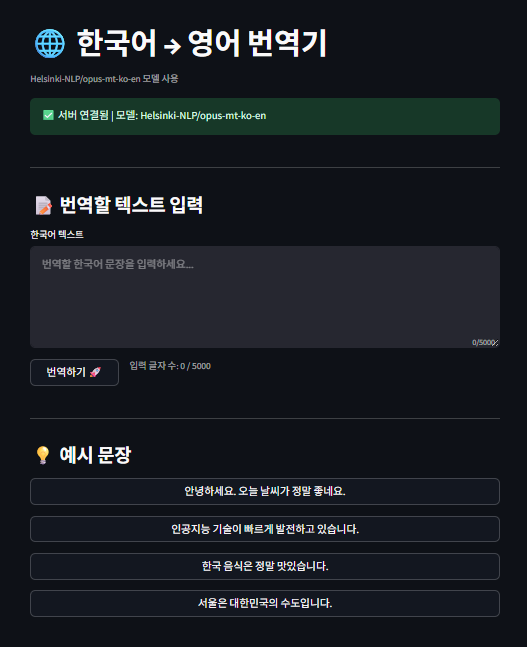

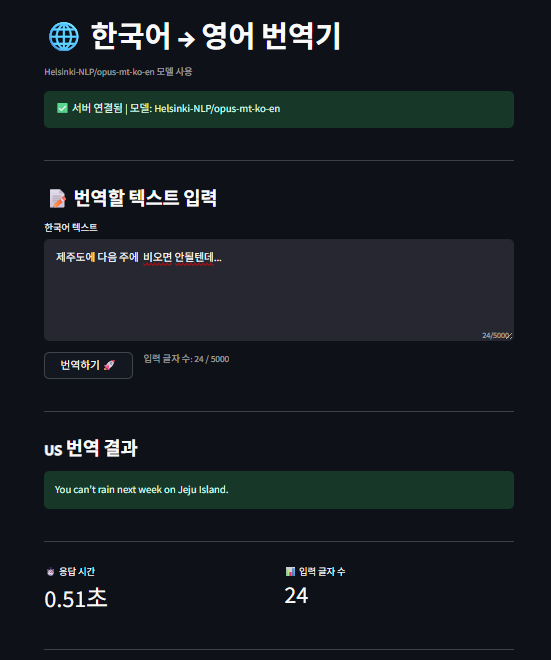

### #6. API 테스트

In [27]:
# 실습용 노트북 파일의 코드 그대로 실행 (잘못된 인증키 테스트)

import requests

API_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "test-key-001"}    # 잘못된 인증키 적용

# health check
print(requests.get(f"{API_URL}/health").json())

# 추론 테스트 — 본인의 입력에 맞게 수정하세요
response = requests.post(
    f"{API_URL}/predict",
    json={"여기에": "본인의 입력"},   # ← 수정
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")


INFO:     127.0.0.1:49756 - "GET /health HTTP/1.1" 200 OK
{'status': 'ready', 'model': 'Helsinki-NLP/opus-mt-ko-en'}
INFO:     127.0.0.1:49772 - "POST /predict HTTP/1.1" 403 Forbidden
상태: 403
결과: {'detail': '유효하지 않은 API Key입니다.'}


In [28]:
# 자체 테스트 (정상 인증키 적용 및 오류 상황 시험)

import requests

HEADERS = {"X-API-Key": "my-key-12345"}

# ✅ 정상 요청
res = requests.post(
    "http://localhost:8000/predict",
    json={"text": "안녕하세요."},
    headers=HEADERS
)
print("정상:", res.json())

# ❌ API Key 없음
res = requests.post(
    "http://localhost:8000/predict",
    json={"text": "안녕하세요."}
)
print("인증 없음:", res.status_code, res.json())

# ❌ 잘못된 API Key
res = requests.post(
    "http://localhost:8000/predict",
    json={"text": "안녕하세요."},
    headers={"X-API-Key": "wrong-key"}
)
print("잘못된 키:", res.status_code, res.json())


INFO:     127.0.0.1:49784 - "POST /predict HTTP/1.1" 200 OK
정상: {'success': True, 'translated_text': 'Hello.', 'source_text': '안녕하세요.', 'model_name': 'Helsinki-NLP/opus-mt-ko-en'}
INFO:     127.0.0.1:41748 - "POST /predict HTTP/1.1" 401 Unauthorized
인증 없음: 401 {'detail': 'API Key가 없습니다. 헤더에 X-API-Key를 포함하세요.'}
INFO:     127.0.0.1:41758 - "POST /predict HTTP/1.1" 403 Forbidden
잘못된 키: 403 {'detail': '유효하지 않은 API Key입니다.'}
